# Data Cleaning & Validation — Biodiesel Consumption Data
## Repsol Capstone Project — Sprint 2

**Goal:** Fix encoding issues in the processed CSVs, validate completeness, and produce clean datasets ready for feature engineering.

**Inputs:** `data/processed/biodiesel_consumo_limpio.csv`, `data/processed/biodiesel_nacional_regional.csv`  
**Outputs:**
- `data/processed/biodiesel_consumo_limpio_clean.csv` — provincial level, encoding fixed
- `data/processed/biodiesel_nacional_regional_clean.csv` — CCAA + national, encoding fixed
- `data/processed/biodiesel_targets.csv` — España + 4 target regions only

## 0. Setup

### What?
Import libraries and define base paths relative to this notebook's location.

### Why?
Using `pathlib` with `__file__` equivalents (via `Path.cwd()` resolution) ensures the notebook works regardless of which machine runs it, as long as the repo structure is maintained.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Resolve repo root from this notebook's location
NOTEBOOK_DIR = Path().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent
DATA_INPUTS   = REPO_ROOT / 'data' / 'inputs'
DATA_FEATURES = REPO_ROOT / 'data' / 'features'
DATA_OUTPUTS  = REPO_ROOT / 'data' / 'outputs'
FIGURES = REPO_ROOT / 'reports' / 'figures'

print(f"Repo root: {REPO_ROOT}")
print(f"Inputs:   {DATA_INPUTS}")
print(f"Features: {DATA_FEATURES}")
print(f"Outputs:  {DATA_OUTPUTS}")
print(f"Figures: {FIGURES}")

Repo root: /Users/alberto/My Drive/Dual Degree MIM + MBD'S/MBD'S/Capstone Project/repsol-capstone
Inputs:   /Users/alberto/My Drive/Dual Degree MIM + MBD'S/MBD'S/Capstone Project/repsol-capstone/data/inputs
Features: /Users/alberto/My Drive/Dual Degree MIM + MBD'S/MBD'S/Capstone Project/repsol-capstone/data/features
Outputs:  /Users/alberto/My Drive/Dual Degree MIM + MBD'S/MBD'S/Capstone Project/repsol-capstone/data/outputs
Figures: /Users/alberto/My Drive/Dual Degree MIM + MBD'S/MBD'S/Capstone Project/repsol-capstone/reports/figures


## 1. Load Raw Processed Data

### What?
Load both processed CSVs and expose the encoding corruption in column values.

### Why?
The original CORES raw files were UTF-8. The EDA notebook read them as `latin-1` (mojibake), then saved the corrupted strings to UTF-8 CSVs. The result is double-encoded text: e.g., `Ã­` instead of `í`. We must identify the affected columns before fixing.

In [2]:
# Load with default UTF-8 — this reveals the mojibake strings
df_prov = pd.read_csv(DATA_INPUTS   / 'consumo_biodiesel_provincial.csv')
df_ccaa = pd.read_csv(DATA_INPUTS   / 'consumo_biodiesel_ccaa.csv')

print("=" * 60)
print("biodiesel_consumo_limpio.csv")
print("=" * 60)
print(f"Shape: {df_prov.shape}")
print(f"Columns: {df_prov.columns.tolist()}")
print(f"\nSample CCAA values (corrupted):")
for v in df_prov['CCAA'].unique()[:6]:
    print(f"  {repr(v)}")

print("\n" + "=" * 60)
print("biodiesel_nacional_regional.csv")
print("=" * 60)
print(f"Shape: {df_ccaa.shape}")
print(f"\nAll CCAA values (corrupted):")
for v in sorted(df_ccaa['CCAA'].unique()):
    print(f"  {repr(v)}")

biodiesel_consumo_limpio.csv
Shape: (1872, 5)
Columns: ['Fecha', 'CCAA', 'Provincia', 'Tipo_Producto', 'Consumo_Tm']

Sample CCAA values (corrupted):
  'Andalucía'
  'Aragón'
  'Asturias, Principado de'
  'Balears, Illes'
  'Canarias'
  'Cantabria'

biodiesel_nacional_regional.csv
Shape: (720, 3)

All CCAA values (corrupted):
  'Andalucía'
  'Aragón'
  'Asturias, Principado de'
  'Balears, Illes'
  'Canarias'
  'Cantabria'
  'Castilla - La Mancha'
  'Castilla y León'
  'Cataluña'
  'Ceuta'
  'Comunitat Valenciana'
  'ESPAÑA'
  'Extremadura'
  'Galicia'
  'Madrid, Comunidad de'
  'Melilla'
  'Murcia, Región de'
  'Navarra, Comunidad Foral de'
  'País Vasco'
  'Rioja, La'


## 2. Fix Encoding (Mojibake Repair)

### What?
Repair the corrupted Spanish characters in `CCAA` and `Provincia` columns.

### Why?
The corruption pattern is: UTF-8 bytes were interpreted as latin-1, producing sequences like `Ã­` for `í`. The fix is to re-encode as latin-1 and decode as UTF-8 — reversing the original mistake. This is a standard mojibake repair.

Example: `'AndalucÃ­a'.encode('latin-1').decode('utf-8')` → `'Andalucía'`

In [3]:
def fix_encoding(text: str) -> str:
    """Repair latin-1/UTF-8 mojibake."""
    try:
        return text.encode('latin-1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text  # already clean (ASCII-only values like 'Cantabria')

# --- Apply to provincial dataset ---
df_prov_clean = df_prov.copy()
df_prov_clean['CCAA'] = df_prov_clean['CCAA'].apply(fix_encoding)
df_prov_clean['Provincia'] = df_prov_clean['Provincia'].apply(fix_encoding)

# --- Apply to CCAA/national dataset ---
df_ccaa_clean = df_ccaa.copy()
df_ccaa_clean['CCAA'] = df_ccaa_clean['CCAA'].apply(fix_encoding)

print("=" * 60)
print("CCAA values after fix:")
print("=" * 60)
for v in sorted(df_ccaa_clean['CCAA'].unique()):
    print(f"  {v}")

print("\n" + "=" * 60)
print("Sample provinces after fix:")
print("=" * 60)
for v in sorted(df_prov_clean['Provincia'].unique()):
    print(f"  {v}")

CCAA values after fix:
  Andalucía
  Aragón
  Asturias, Principado de
  Balears, Illes
  Canarias
  Cantabria
  Castilla - La Mancha
  Castilla y León
  Cataluña
  Ceuta
  Comunitat Valenciana
  ESPAÑA
  Extremadura
  Galicia
  Madrid, Comunidad de
  Melilla
  Murcia, Región de
  Navarra, Comunidad Foral de
  País Vasco
  Rioja, La

Sample provinces after fix:
  Albacete
  Alicante/Alacant
  Almería
  Araba/Álava
  Asturias
  Badajoz
  Balears, Illes
  Barcelona
  Bizkaia
  Burgos
  Cantabria
  Castellón/Castelló
  Ceuta
  Ciudad Real
  Coruña, A
  Cuenca
  Cáceres
  Cádiz
  Córdoba
  Gipuzkoa
  Girona
  Granada
  Guadalajara
  Huelva
  Huesca
  Jaén
  León
  Lleida
  Lugo
  Madrid
  Melilla
  Murcia
  Málaga
  Navarra
  Ourense
  Palencia
  Palmas, Las
  Pontevedra
  Rioja, La
  Salamanca
  Santa Cruz de Tenerife
  Segovia
  Sevilla
  Soria
  Tarragona
  Teruel
  Toledo
  Valencia/València
  Valladolid
  Zamora
  Zaragoza
  Ávila


## 3. Completeness Validation

### What?
Verify that every CCAA has exactly 36 monthly observations (Jan 2023 – Dec 2025), that there are no null values, and that the date range is complete.

### Why?
Missing months in a time series create gaps that break lag features and model training. We need to confirm the dataset is a balanced panel before proceeding.

In [4]:
print("=" * 60)
print("NULL CHECK")
print("=" * 60)
print("biodiesel_consumo_limpio_clean:")
print(df_prov_clean.isnull().sum())
print("\nbiodiesel_nacional_regional_clean:")
print(df_ccaa_clean.isnull().sum())

print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)
print(f"Period: {df_ccaa_clean['Fecha'].min()} → {df_ccaa_clean['Fecha'].max()}")
n_months = df_ccaa_clean['Fecha'].nunique()
print(f"Unique months: {n_months} (expected 36)")

# Check all 36 months are present for every CCAA
obs_per_ccaa = df_ccaa_clean.groupby('CCAA')['Fecha'].count()
print("\n" + "=" * 60)
print("OBSERVATIONS PER CCAA (expected 36 each)")
print("=" * 60)
anomalies = obs_per_ccaa[obs_per_ccaa != 36]
if anomalies.empty:
    print("All CCAAAs have exactly 36 monthly observations.")
else:
    print("Anomalies found:")
    print(anomalies)

# Verify expected months exist
expected_months = pd.date_range('2023-01', periods=36, freq='MS').strftime('%Y-%m').tolist()
actual_months = sorted(df_ccaa_clean['Fecha'].unique())
missing = set(expected_months) - set(actual_months)
extra = set(actual_months) - set(expected_months)
print(f"\nMissing months: {missing if missing else 'None'}")
print(f"Extra months:   {extra if extra else 'None'}")

NULL CHECK
biodiesel_consumo_limpio_clean:
Fecha            0
CCAA             0
Provincia        0
Tipo_Producto    0
Consumo_Tm       0
dtype: int64

biodiesel_nacional_regional_clean:
Fecha         0
CCAA          0
Consumo_Tm    0
dtype: int64

DATE RANGE
Period: 2023-01 → 2025-12
Unique months: 36 (expected 36)

OBSERVATIONS PER CCAA (expected 36 each)
All CCAAAs have exactly 36 monthly observations.

Missing months: None
Extra months:   None


## 4. Zero Value Analysis

### What?
Identify which regions have zero consumption and whether zeros appear early in the series (suggesting late market adoption) or scattered (suggesting data gaps).

### Why?
Zeros are valid in eco-fuel consumption — biodiesel adoption was very low in 2023 and grew rapidly. However, zeros that appear after a period of non-zero values could indicate missing data and must be treated differently in models.

% MONTHS WITH ZERO CONSUMPTION PER CCAA
CCAA
Ceuta                          100.000000
Melilla                        100.000000
Balears, Illes                  86.111111
Canarias                        58.333333
Rioja, La                       47.222222
Asturias, Principado de         36.111111
Cantabria                       33.333333
Extremadura                     33.333333
Murcia, Región de               27.777778
Castilla y León                 25.000000
Navarra, Comunidad Foral de     25.000000
Galicia                         22.222222
Castilla - La Mancha            19.444444
Andalucía                       19.444444
Comunitat Valenciana            13.888889
Aragón                           5.555556
Madrid, Comunidad de             5.555556
Cataluña                         0.000000
País Vasco                       0.000000

TARGET REGIONS — ZERO CHECK
  Madrid, Comunidad de: 2 zero months out of 36
  Cataluña: 0 zero months out of 36
  Andalucía: 7 zero months out of 36
  Comun

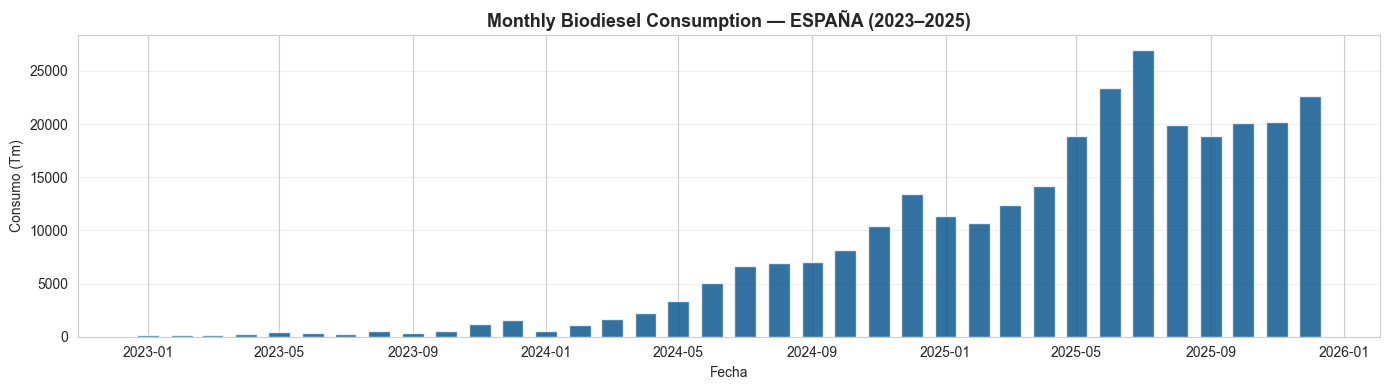

Figure saved: 05_consumo_nacional_clean.png


In [5]:
df_plot = df_ccaa_clean[df_ccaa_clean['CCAA'] != 'ESPAÑA'].copy()

# Percentage of zero months per CCAA
zero_pct = (
    df_plot.groupby('CCAA')['Consumo_Tm']
    .apply(lambda x: (x == 0).mean() * 100)
    .sort_values(ascending=False)
    .rename('Pct_Cero')
)

print("=" * 60)
print("% MONTHS WITH ZERO CONSUMPTION PER CCAA")
print("=" * 60)
print(zero_pct.to_string())

# Check target regions specifically
TARGET_REGIONS = ['Madrid, Comunidad de', 'Cataluña', 'Andalucía', 'Comunitat Valenciana', 'ESPAÑA']
print("\n" + "=" * 60)
print("TARGET REGIONS — ZERO CHECK")
print("=" * 60)
for region in TARGET_REGIONS:
    matches = [c for c in df_ccaa_clean['CCAA'].unique() if region.lower() in c.lower()]
    for m in matches:
        data = df_ccaa_clean[df_ccaa_clean['CCAA'] == m]
        zeros = (data['Consumo_Tm'] == 0).sum()
        print(f"  {m}: {zeros} zero months out of 36")

# Visualize zero distribution over time for ESPAÑA
df_esp = df_ccaa_clean[df_ccaa_clean['CCAA'] == 'ESPAÑA'].copy()
df_esp['Fecha_dt'] = pd.to_datetime(df_esp['Fecha'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df_esp['Fecha_dt'], df_esp['Consumo_Tm'], color='#004E89', width=20, alpha=0.8)
ax.set_title('Monthly Biodiesel Consumption — ESPAÑA (2023–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo (Tm)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGURES / '05_consumo_nacional_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 05_consumo_nacional_clean.png")

## 5. Extract Target Regions

### What?
Create a filtered dataset containing only the 5 target series: ESPAÑA (national) + Madrid, Cataluña, Andalucía, Comunitat Valenciana (the 4 regional targets).

### Why?
The models will be trained separately for each target. Having a clean, narrow dataset avoids accidentally mixing in non-target CCAAAs during feature engineering and model training.

TARGET DATASET SUMMARY
Shape: (180, 4)

Rows per target:
Target
Andalucía    36
Cataluña     36
Madrid       36
Nacional     36
Valencia     36
Name: Consumo_Tm, dtype: int64

Consumption stats per target (Tm):
           min    mean    max     std
Target                               
Andalucía    0   632.0   2664   738.0
Cataluña    78  1256.0   3811  1312.0
Madrid       0  1149.0   3854  1276.0
Nacional   162  8122.0  27001  8423.0
Valencia     0   396.0   1448   425.0


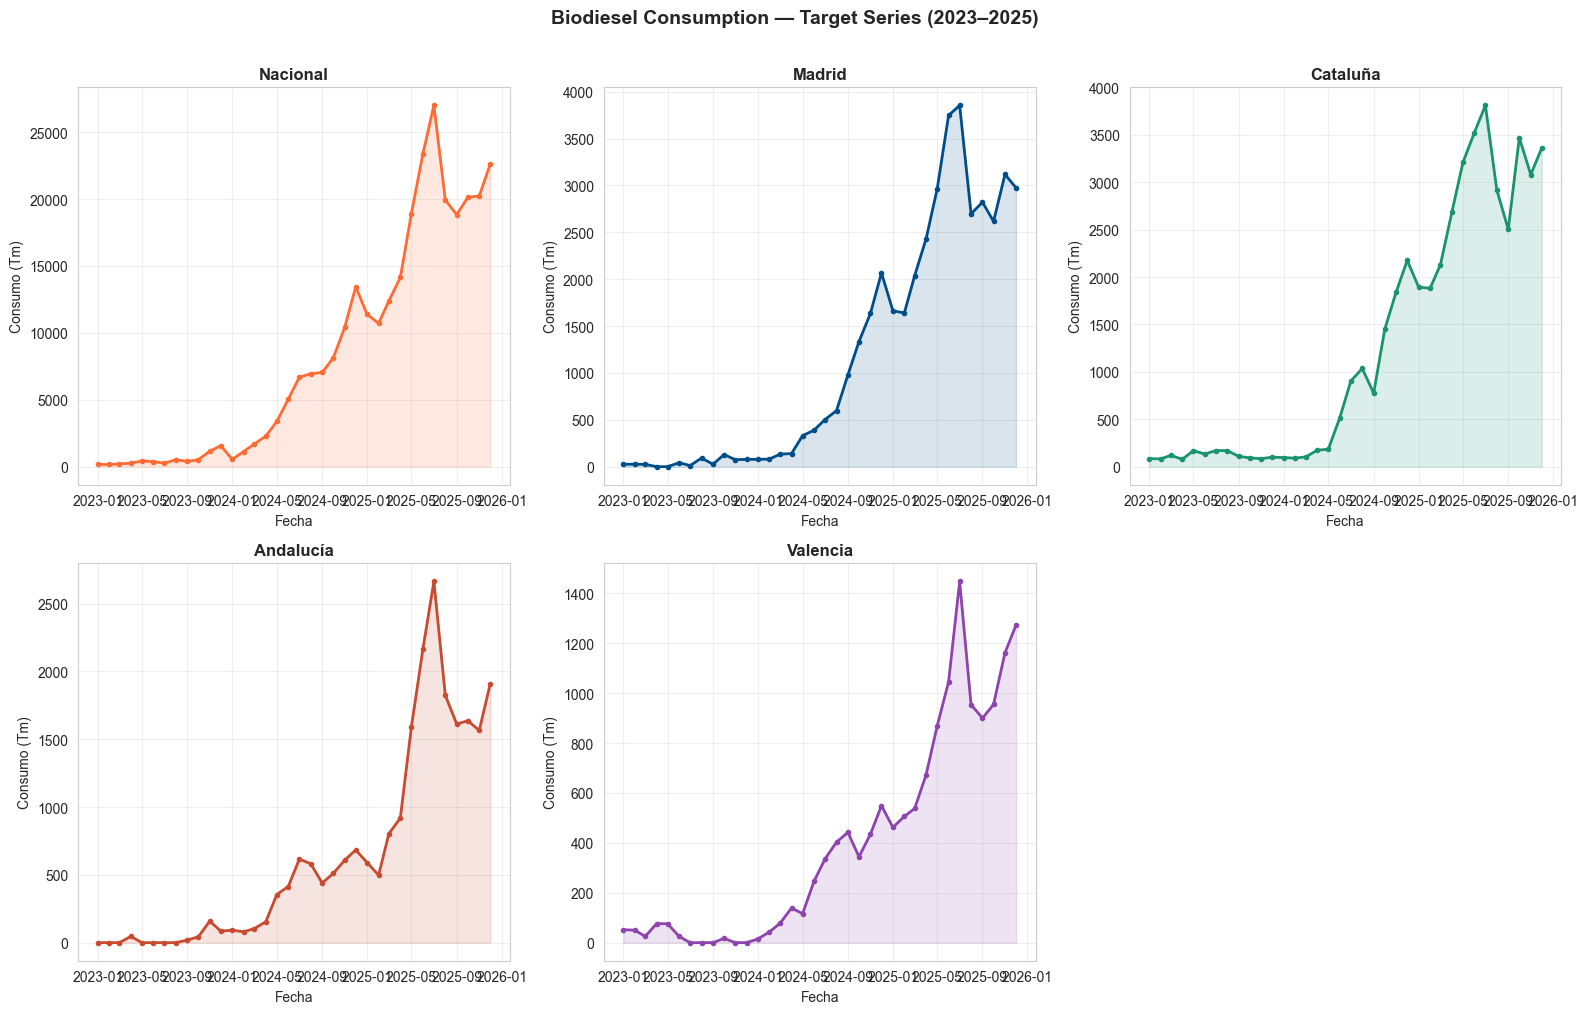

Figure saved: 06_target_series.png


In [6]:
# Map full CCAA names to short labels for convenience
TARGET_MAP = {
    'ESPAÑA': 'Nacional',
    'Madrid, Comunidad de': 'Madrid',
    'Cataluña': 'Cataluña',
    'Andalucía': 'Andalucía',
    'Comunitat Valenciana': 'Valencia',
}

df_targets = df_ccaa_clean[df_ccaa_clean['CCAA'].isin(TARGET_MAP.keys())].copy()
df_targets['Target'] = df_targets['CCAA'].map(TARGET_MAP)
df_targets = df_targets.sort_values(['Target', 'Fecha']).reset_index(drop=True)

print("=" * 60)
print("TARGET DATASET SUMMARY")
print("=" * 60)
print(f"Shape: {df_targets.shape}")
print(f"\nRows per target:")
print(df_targets.groupby('Target')['Consumo_Tm'].count())
print(f"\nConsumption stats per target (Tm):")
print(df_targets.groupby('Target')['Consumo_Tm'].agg(['min', 'mean', 'max', 'std']).round(0))

# Plot all 5 targets together
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = {'Nacional': '#FF6B35', 'Madrid': '#004E89', 'Cataluña': '#1A936F',
          'Andalucía': '#C84B31', 'Valencia': '#8E44AD'}

for i, (label, color) in enumerate(colors.items()):
    data = df_targets[df_targets['Target'] == label].copy()
    data['Fecha_dt'] = pd.to_datetime(data['Fecha'])
    axes[i].plot(data['Fecha_dt'], data['Consumo_Tm'], color=color, linewidth=2, marker='o', markersize=3)
    axes[i].fill_between(data['Fecha_dt'], data['Consumo_Tm'], alpha=0.15, color=color)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Fecha')
    axes[i].set_ylabel('Consumo (Tm)')
    axes[i].grid(True, alpha=0.3)

axes[5].set_visible(False)
fig.suptitle('Biodiesel Consumption — Target Series (2023–2025)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '06_target_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 06_target_series.png")

## 6. Save Clean Files

### What?
Write the three clean output CSVs to `data/processed/`.

### Why?
Saving clean, versioned artifacts at each sprint stage means downstream notebooks (feature engineering, modeling) always read validated data — not re-running the same cleaning steps.

In [7]:
# --- Save provincial clean ---
out_prov = DATA_INPUTS   / 'consumo_biodiesel_provincial.csv'
df_prov_clean.to_csv(out_prov, index=False, encoding='utf-8')
print(f"Saved: {out_prov.name}  ({len(df_prov_clean)} rows)")

# --- Save CCAA/national clean ---
out_ccaa = DATA_INPUTS / 'consumo_biodiesel_ccaa.csv'
df_ccaa_clean.to_csv(out_ccaa, index=False, encoding='utf-8')
print(f"Saved: {out_ccaa.name}  ({len(df_ccaa_clean)} rows)")

# --- Save targets only ---
out_targets = DATA_INPUTS   / 'consumo_biodiesel_targets.csv'
df_targets.to_csv(out_targets, index=False, encoding='utf-8')
print(f"Saved: {out_targets.name}  ({len(df_targets)} rows)")

# Quick verification: confirm CCAA names are now correct
verify = pd.read_csv(out_ccaa)
print("\nVerification — CCAA values in saved file:")
for v in sorted(verify['CCAA'].unique()):
    print(f"  {v}")

Saved: consumo_biodiesel_provincial.csv  (1872 rows)
Saved: consumo_biodiesel_ccaa.csv  (720 rows)
Saved: consumo_biodiesel_targets.csv  (180 rows)

Verification — CCAA values in saved file:
  Andalucía
  Aragón
  Asturias, Principado de
  Balears, Illes
  Canarias
  Cantabria
  Castilla - La Mancha
  Castilla y León
  Cataluña
  Ceuta
  Comunitat Valenciana
  ESPAÑA
  Extremadura
  Galicia
  Madrid, Comunidad de
  Melilla
  Murcia, Región de
  Navarra, Comunidad Foral de
  País Vasco
  Rioja, La


## 7. Summary

### Sprint 2 — Data Cleaning: DONE ✅

| Check | Result |
|-------|--------|
| Encoding fix | Mojibake repaired in CCAA and Provincia columns |
| Null values | None in any dataset |
| Date completeness | 36 months (2023-01 → 2025-12) for all CCAAAs |
| Balanced panel | 36 observations per CCAA ✓ |
| Target regions | Madrid, Cataluña, Andalucía, Valencia + España isolated |

### Output files
- `data/processed/biodiesel_consumo_limpio_clean.csv` — 1,872 rows, provincial level
- `data/processed/biodiesel_nacional_regional_clean.csv` — 720 rows, all CCAAAs
- `data/processed/biodiesel_targets.csv` — 180 rows, 5 target series

### Next step → `03_external_data.ipynb`
Download and process INE macroeconomic variables (IPI industrial, tasa de paro EPA) and DGT fleet data to build the feature matrix.